<a href="https://colab.research.google.com/github/peanutpirate/Week6_Store_Sales_Time_Series_Forecasting/blob/notebooks/store_sales_time_series_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 Store Sales – Time Series Forecasting

### 📊 Project Overview
This project is part of the **Kaggle Store Sales Time Series Forecasting Competition**.

**Objective:**  
The goal is to analyze historical daily sales data from *Corporación Favorita* (a large Ecuadorian grocery retailer) to identify key trends, seasonal patterns, and external factors influencing sales performance. Accurate sales forecasting is critical in the retail industry for effective inventory management, promotion planning, and revenue optimization.

This competition focuses on **multiple related time series**, making it a practical real-world forecasting problem.

**Key Goals:**
* 🔍 **Exploratory Data Analysis (EDA):** Understand sales distributions, trends, and seasonality.
* 🧹 **Data Cleaning & Preprocessing:** Handle missing values and ensure time-aware data preparation.
* 🧠 **Feature Engineering:** Create lag, rolling, and calendar-based features for forecasting.
* 📈 **Forecasting Models:** Develop and evaluate models to predict future daily sales.

**Tools & Libraries:**  
`Python`, `Pandas`, `NumPy`, `Scikit-learn`, `LightGBM`, `Matplotlib`, `Seaborn`  

*Developed in Google Colab.*

🔗 [Kaggle Store Sales Competition](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/overview)


## 1. Imports and Environment Setup

In [ ]:
# 1. Standard Libraries
import os
import numpy as np
import pandas as pd

# 2. Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Machine Learning & Forecasting Tools
import lightgbm as lgb
from sklearn.metrics import mean_squared_log_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 4. Global Configuration
import warnings
warnings.filterwarnings('ignore') # Let's hide unneccassary findings

# Ensuring all columns are visible during EDA
pd.set_option('display.max_columns', None) # Let's see whole rows
pd.set_option('display.float_format', lambda x: '%.3f' % x) # Let's make numbers more readable
sns.set_style("whitegrid")

# Project Constraints & Strategy
# - This project uses time-based validation to preserve chronological integrity.
# - The evaluation metric is Root Mean Squared Logarithmic Error (RMSLE).

print("✅ Libraries imported and environment setup complete!")

✅ Libraries imported and environment setup complete!


## 2. Data Loading

In this section, all datasets provided in the Kaggle competition are loaded.
These datasets include sales history, store metadata, oil prices, holidays,
and daily transaction counts.

In [ ]:
# Define data path (update if files are stored in a subdirectory)
path = ""

# Load datasets
train = pd.read_csv(path + 'train.csv', parse_dates=['date'])
test = pd.read_csv(path + 'test.csv', parse_dates=['date'])
stores = pd.read_csv(path + 'stores.csv')
oil = pd.read_csv(path + 'oil.csv', parse_dates=['date'])
holidays = pd.read_csv(path + 'holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv(path + 'transactions.csv', parse_dates=['date'])

# Quick overview of dataset dimensions
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Stores shape: {stores.shape}")
print(f"Oil prices shape: {oil.shape}")
print(f"Holidays shape: {holidays.shape}")
print(f"Transactions shape: {transactions.shape}")

# Preview main training dataset
train.head()

Train shape: (3000888, 6)
Test shape: (28512, 5)
Stores shape: (54, 5)
Oil prices shape: (1218, 2)
Holidays shape: (350, 6)
Transactions shape: (83488, 3)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,1,2013-01-01,1,BABY CARE,0.000,0
2,2,2013-01-01,1,BEAUTY,0.000,0
3,3,2013-01-01,1,BEVERAGES,0.000,0
4,4,2013-01-01,1,BOOKS,0.000,0


## 3. Initial Data Overview

In [ ]:
# Section 3: Data Loading
# Loading datasets from the Kaggle Store Sales Time Series Forecasting competition

# Note: Update 'path' if files are stored in a subdirectory (e.g. '/content/drive/MyDrive/data/')
path = ""

# Load datasets with date parsing for time series awareness
train = pd.read_csv(path + 'train.csv', parse_dates=['date'])
test = pd.read_csv(path + 'test.csv', parse_dates=['date'])
stores = pd.read_csv(path + 'stores.csv')
oil = pd.read_csv(path + 'oil.csv', parse_dates=['date'])
holidays = pd.read_csv(path + 'holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv(path + 'transactions.csv', parse_dates=['date'])

# Preview training data
print("Training data loaded successfully:")
display(train.head())

# Check data types (date column should be datetime64[ns])
print("\nData Types Summary:")
print(train.dtypes)

# Basic sanity checks
print("\nDate Range:", train['date'].min(), "to", train['date'].max())
print("Target Variable:", 'sales')

Training data loaded successfully:


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,1,2013-01-01,1,BABY CARE,0.000,0
2,2,2013-01-01,1,BEAUTY,0.000,0
3,3,2013-01-01,1,BEVERAGES,0.000,0
4,4,2013-01-01,1,BOOKS,0.000,0



Data Types Summary:
id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object

Date Range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Target Variable: sales


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Section 3: Initial Data Overview
# Before diving into visualizations, we need to understand the structure, granularity, and health of our datasets.

# Security Check: Handle corrupted date strings (e.g., "2014-") using errors='coerce'
# This will turn invalid dates into NaT (Not a Time) instead of crashing the program.
train['date'] = pd.to_datetime(train['date'], errors='coerce')
oil['date'] = pd.to_datetime(oil['date'], errors='coerce')
holidays['date'] = pd.to_datetime(holidays['date'], errors='coerce')
transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce')

# Identify if we have any corrupted dates that turned into NaT
corrupted_dates = train[train['date'].isna()]
if not corrupted_dates.empty:
    print(f"⚠️ Found {len(corrupted_dates)} corrupted date entries!")
    print("Sample of corrupted rows:")
    display(corrupted_dates.head())
    # Drop corrupted rows to proceed with analysis
    train = train.dropna(subset=['date'])

print("--- 3.1. Data Granularity & Scope ---")
# Checking time range and unique identifiers
# We use .date() for a cleaner output in the print statement
print(f"Date Range: {train['date'].min().date()} to {train['date'].max().date()}")
print(f"Number of Unique Stores: {train['store_nbr'].nunique()}")
print(f"Number of Product Families: {train['family'].nunique()}")
print(f"Data Granularity: Daily sales per store per product family")

# Basic information about the training dataset
print("\n🔎 Dataset Info:")
train.info()

# Missing value summary (Count and Percentage)
print("\n🧹 Missing Values Summary:")
missing_count = train.isnull().sum()
missing_percent = (train.isnull().mean() * 100)
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage (%)': missing_percent
}).sort_values(by='Missing Count', ascending=False)
display(missing_summary)

# Unique value counts for categorical columns
print("\n🏬 Unique Stores:", train['store_nbr'].nunique())
print("🧺 Unique Product Families:", train['family'].nunique())

# Check data granularity details
num_unique_dates = train['date'].nunique()
print("\n📅 Number of unique dates:", num_unique_dates)
print("Total rows in Train:", train.shape[0])

# Confirm expected row count if the dataset was fully populated
# (Stores * Families * Dates)
expected_rows = train['store_nbr'].nunique() * train['family'].nunique() * num_unique_dates
print("\nExpected rows if fully populated:", expected_rows)
print(f"Missing rows in sequence: {expected_rows - train.shape[0]}")

print("\n--- 3.2. Missing Value Analysis (Other Datasets) ---")
datasets = {
    'Oil': oil,
    'Holidays': holidays,
    'Stores': stores,
    'Transactions': transactions
}

for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    if missing > 0:
        print(f"{name}: Found {missing} missing values")
    else:
        print(f"{name}: No missing values")

# Specific check for Oil as it is a critical external feature
print("\nOil Data Missing Details:")
print(oil.isnull().sum())

print("\n--- 3.3. Basic Statistics ---")
display(train.describe())

--- 3.1. Data Granularity & Scope ---
Date Range: 2013-01-01 to 2017-08-15
Number of Unique Stores: 54
Number of Product Families: 33
Data Granularity: Daily sales per store per product family

🔎 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB

🧹 Missing Values Summary:


,Missing Count,Percentage (%)
id,0,0.000
date,0,0.000
store_nbr,0,0.000
family,0,0.000
sales,0,0.000
onpromotion,0,0.000



🏬 Unique Stores: 54
🧺 Unique Product Families: 33

📅 Number of unique dates: 1684
Total rows in Train: 3000888

Expected rows if fully populated: 3000888
Missing rows in sequence: 0

--- 3.2. Missing Value Analysis (Other Datasets) ---
Oil: Found 43 missing values
Holidays: No missing values
Stores: No missing values
Transactions: No missing values

Oil Data Missing Details:
date           0
dcoilwtico    43
dtype: int64

--- 3.3. Basic Statistics ---


,id,date,store_nbr,sales,onpromotion
count,3000888.000,3000888,3000888.000,3000888.000,3000888.000
mean,1500443.500,2015-04-24 08:27:04.703088384,27.500,357.776,2.603
min,0.000,2013-01-01 00:00:00,1.000,0.000,0.000
25%,750221.750,2014-02-26 18:00:00,14.000,0.000,0.000
50%,1500443.500,2015-04-24 12:00:00,27.500,11.000,0.000
75%,2250665.250,2016-06-19 06:00:00,41.000,195.847,0.000
max,3000887.000,2017-08-15 00:00:00,54.000,124717.000,741.000
std,866281.892,NaN,15.586,1101.998,12.219


Note: The dataset is sparse, meaning not all store-family-date combinations exist.
This is typical in real-world retail data and must be handled carefully in modeling.


Transactions data will be explored as a potential proxy for customer traffic and demand signals.

## 4. Exploratory Data Analysis
In this section, we explore the main characteristics of the sales time series,
including distribution, trends, seasonality, and the effect of promotions.

### 4.1 Sales Distribution
Understanding the distribution of daily sales helps identify skewness,
outliers, and the overall scale of the target variable.

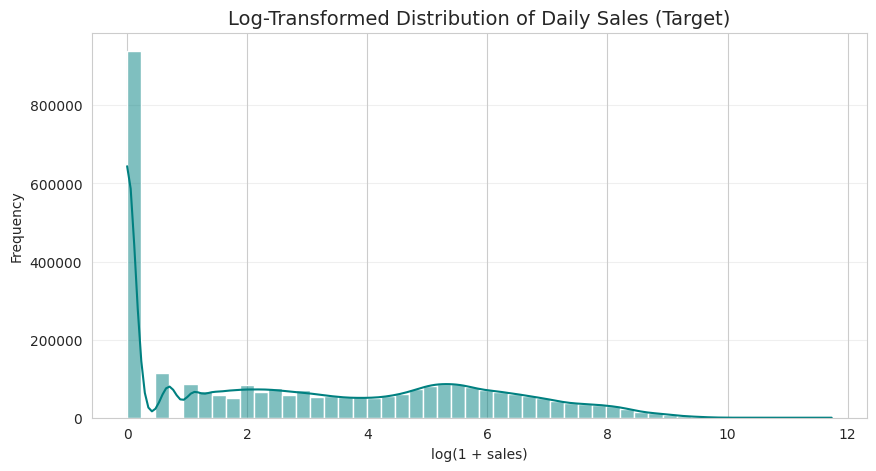

In [ ]:
# 4.1. Log-Transformed Sales Distribution
# This is crucial because the competition uses RMSLE as the metric.
# It helps us see how the model will "perceive" the target.
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(train['sales']), bins=50, kde=True, color='teal')
plt.title("Log-Transformed Distribution of Daily Sales (Target)", fontsize=14)
plt.xlabel("log(1 + sales)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

### 4.2 Time Range & Trends
We examine overall sales trends over time to identify growth patterns
and long-term movements in the data.

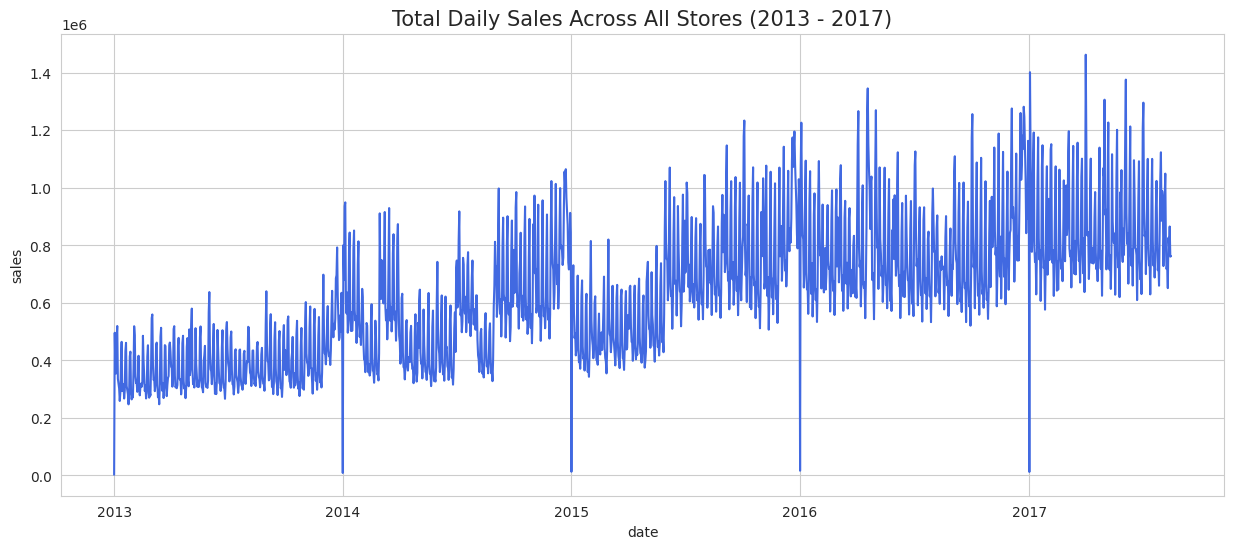

In [ ]:
daily_sales = train.groupby('date')[['sales']].sum().reset_index()
plt.figure(figsize=(15, 6))
sns.lineplot(data=daily_sales, x='date', y='sales', color='royalblue')
plt.title('Total Daily Sales Across All Stores (2013 - 2017)', fontsize=15)
plt.show()

### 4.3 Seasonality Analysis

This section explores weekly and yearly seasonality patterns in sales.

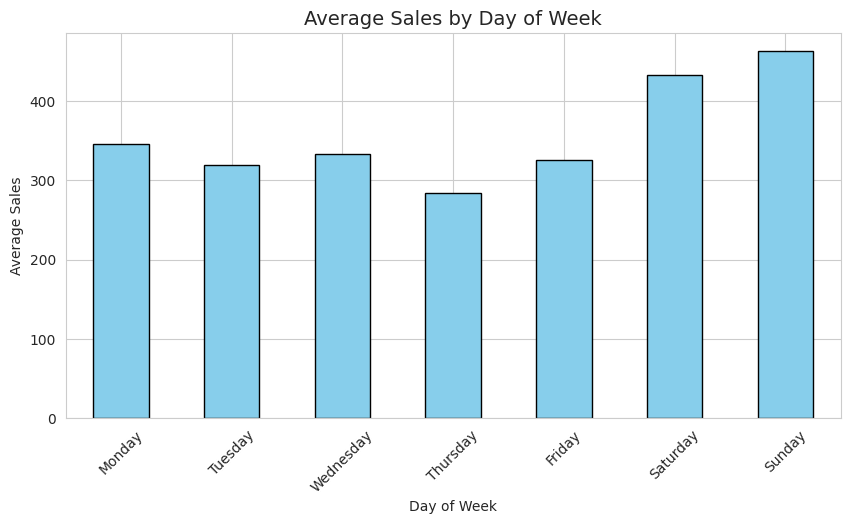

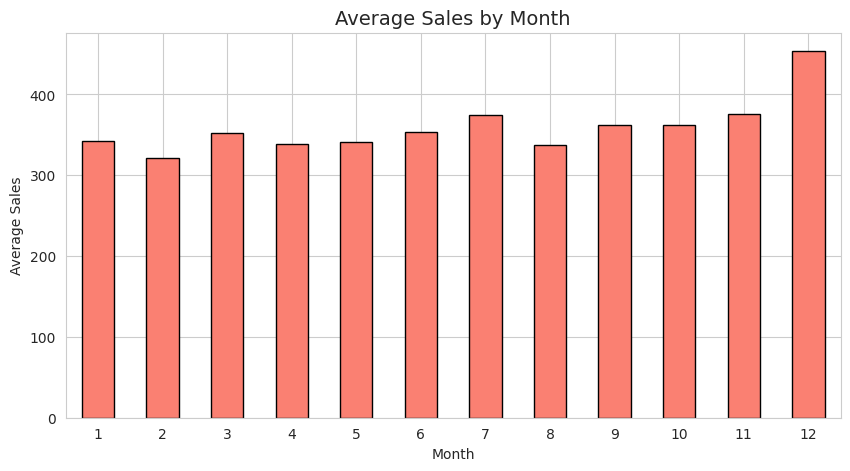

In [ ]:
# Weekly seasonality
train['day_of_week'] = train['date'].dt.day_name()
weekly_sales = train.groupby('day_of_week')['sales'].mean()

# Reorder days for a logical sequence
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_sales = weekly_sales.reindex(days_order)

plt.figure(figsize=(10, 5))
weekly_sales.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Average Sales by Day of Week", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.show()

# Yearly seasonality (Monthly)
train['month'] = train['date'].dt.month
monthly_sales = train.groupby('month')['sales'].mean()

plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='bar', color='salmon', edgecolor='black')
plt.title("Average Sales by Month", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.show()

### 4.4 Effect of Promotions
Understanding the categorical impact of promotions on sales volume.

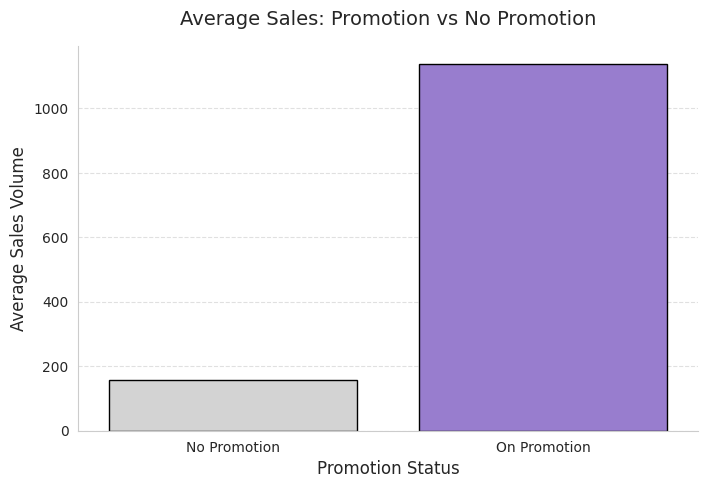

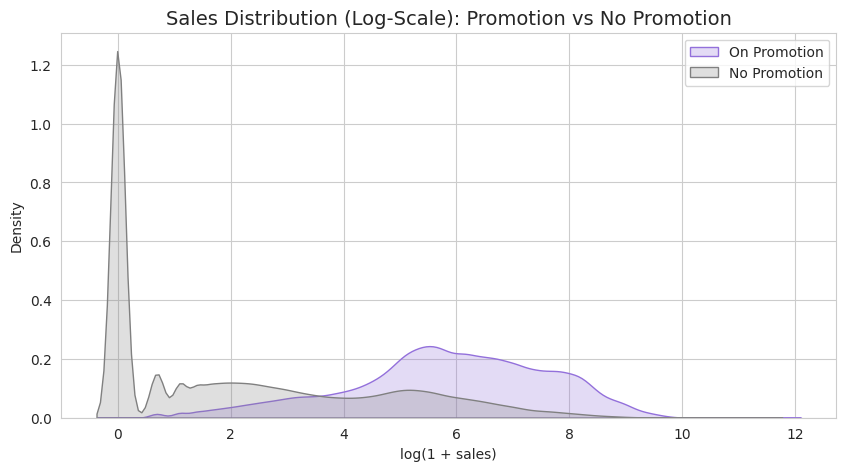

In [ ]:
# Promotion effect: Average sales comparison
promo_sales = (
    train.assign(is_promo=train['onpromotion'] > 0)
         .groupby('is_promo')['sales']
         .mean()
         .rename(index={False: 'No Promotion', True: 'On Promotion'})
)

plt.figure(figsize=(8, 5))
# Using seaborn barplot for a cleaner look and better axis control
sns.barplot(x=promo_sales.index, y=promo_sales.values, palette=['#D3D3D3', '#9370DB'], edgecolor='black')
plt.title("Average Sales: Promotion vs No Promotion", fontsize=14, pad=15)
plt.xlabel("Promotion Status", fontsize=12)
plt.ylabel("Average Sales Volume", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine() # Removes the top and right borders for a cleaner aesthetic
plt.show()

# Distribution comparison: Visualizing the shift in sales density
plt.figure(figsize=(10, 5))
sns.kdeplot(np.log1p(train.loc[train['onpromotion'] > 0, 'sales']), label='On Promotion', fill=True, color='mediumpurple')
sns.kdeplot(np.log1p(train.loc[train['onpromotion'] == 0, 'sales']), label='No Promotion', fill=True, color='grey')
plt.title("Sales Distribution (Log-Scale): Promotion vs No Promotion", fontsize=14)
plt.xlabel("log(1 + sales)")
plt.legend()
plt.show()

### 4.5 External Factors: Oil Prices (WTI)

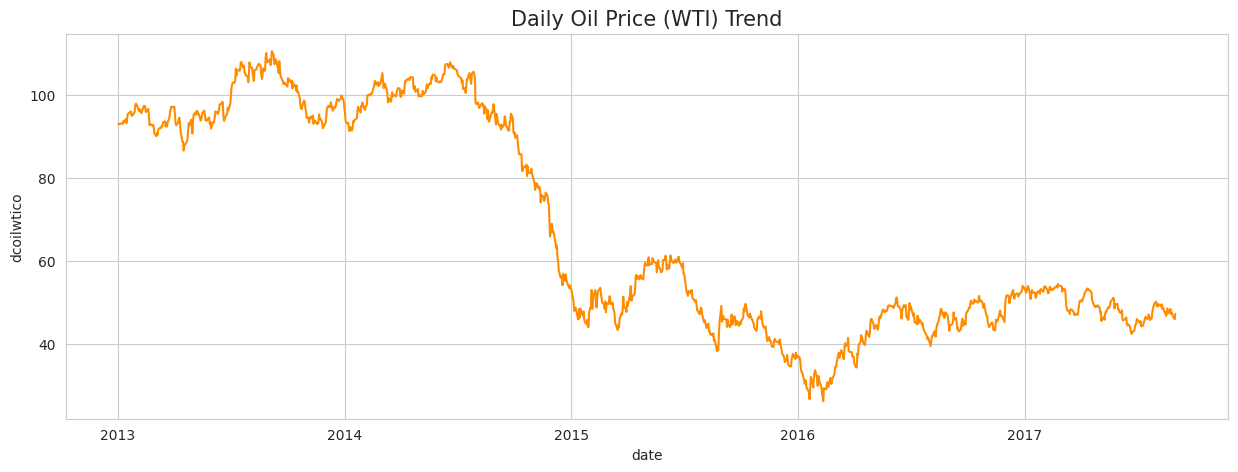

In [ ]:
plt.figure(figsize=(15, 5))
sns.lineplot(data=oil, x='date', y='dcoilwtico', color='darkorange')
plt.title('Daily Oil Price (WTI) Trend', fontsize=15)
plt.show()

### 4.6. Sales Distribution by Store Type

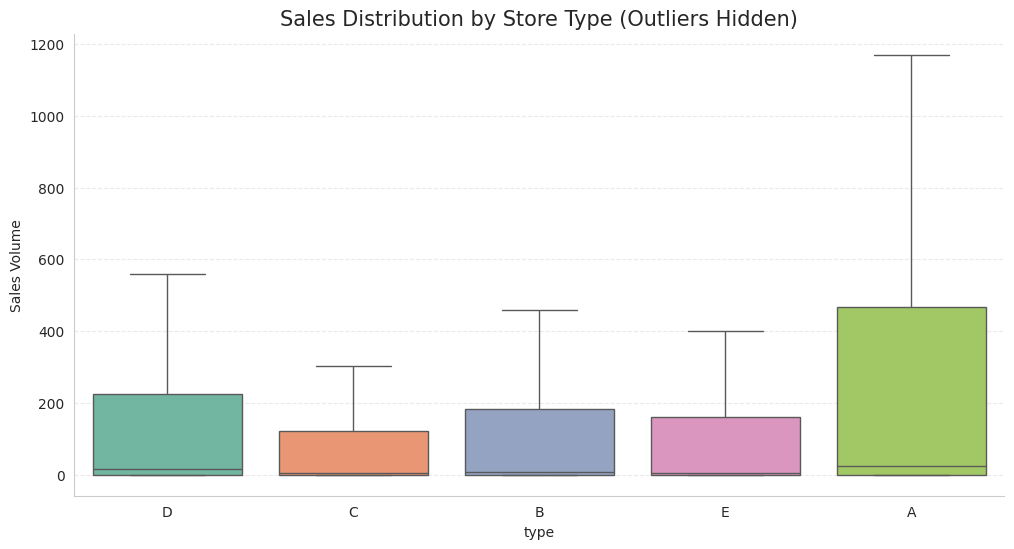

In [ ]:
# Cleaning the plot by removing outliers (flierprops) and handling the log scale better
store_sales = train.merge(stores, on='store_nbr')
plt.figure(figsize=(12, 6))

# showfliers=False removes the messy dots (outliers)
# Using log1p on y directly and then plotting is often cleaner than plt.yscale('log')
sns.boxplot(data=store_sales, x='type', y='sales', palette='Set2', showfliers=False)
plt.title('Sales Distribution by Store Type (Outliers Hidden)', fontsize=15)
plt.ylabel('Sales Volume')
plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.show()

### EDA Summary & Key Insights

The exploratory analysis reveals several important characteristics of the sales time series:

• **Target Distribution**
Daily sales are heavily right-skewed. After applying a log(1 + sales) transformation, the distribution becomes much more symmetric, validating the use of RMSLE as the evaluation metric and motivating log-based modeling strategies.

• **Overall Trend**
Total daily sales exhibit clear long-term trends with noticeable fluctuations across years. The rolling behavior suggests non-stationarity, indicating that time-aware features will be critical for modeling.

• **Seasonality**
Strong weekly seasonality is present, with weekends generally outperforming weekdays.
Monthly patterns highlight clear yearly seasonality, suggesting that calendar-based features (day-of-week, month) will significantly improve predictive performance.

• **Effect of Promotions**
Promotions have a substantial and consistent positive impact on sales.
Both the average sales comparison and log-scale density plots show a clear upward shift during promotional periods, making `onpromotion` one of the most influential predictors.

• **External Factors (Oil Prices)**
Oil prices show high volatility over time and may correlate with broader economic behavior.
While the relationship is not directly causal, oil prices represent a meaningful external signal worth incorporating into the model.

• **Store-Level Heterogeneity**
Sales distributions differ significantly across store types.
This indicates structural differences in store behavior, suggesting that store metadata (type, cluster, city/state) should be treated as core categorical features.

---

### Modeling Implications

Based on these findings, the model should:
- Use log-transformed targets
- Incorporate rich time-based features
- Explicitly model promotional effects
- Leverage store metadata for segmentation
- Integrate external signals such as oil prices

These insights directly inform the upcoming feature engineering and modeling stages.

## 5. Data Preprocessing

Time-aware preprocessing is critical in time series forecasting to avoid data leakage
and overly optimistic validation results.

Unlike traditional machine learning problems, future information must never be used
— even indirectly — when preparing training data. All transformations, imputations,
and feature constructions are therefore performed with strict chronological awareness.

This section focuses on building a clean and leakage-safe dataset that reflects
real-world forecasting conditions.

### 5.1 Handling Missing Values
Missing values in time series data must be handled carefully to avoid introducing
future information into the training process.

In this section, we analyze and impute missing values using only historical context,
ensuring chronological consistency.

In [ ]:
# Missing values overview for main datasets
missing_summary = {
    'Train': train.isnull().sum(),
    'Oil': oil.isnull().sum(),
    'Holidays': holidays.isnull().sum(),
    'Transactions': transactions.isnull().sum(),
    'Stores': stores.isnull().sum()
}

print("🔎 Missing Values Summary:")
for name, summary in missing_summary.items():
    print(f"\n{name} Dataset:")
    display(summary[summary > 0])

🔎 Missing Values Summary:

Train Dataset:


,0



Oil Dataset:


,0
dcoilwtico,43



Holidays Dataset:


,0



Transactions Dataset:


,0



Stores Dataset:


,0


#### 🛢️ 5.1.2 Oil Prices – Forward Fill (Time-Aware)

In [ ]:
# Sort by date to ensure chronological order
oil = oil.sort_values('date')

# Forward fill missing oil prices (using past information only)
oil['dcoilwtico'] = oil['dcoilwtico'].ffill()

# Optional: backward fill only for initial missing values (safe at the start)
oil['dcoilwtico'] = oil['dcoilwtico'].bfill()

print("✅ Missing oil prices handled using time-aware filling.")

✅ Missing oil prices handled using time-aware filling.


#### 🏷️ 5.1.3 Promotions – Handling Missing Values

In [ ]:
# Promotions missing values are treated as no promotion
train['onpromotion'] = train['onpromotion'].fillna(0)
test['onpromotion'] = test['onpromotion'].fillna(0)

print("✅ Missing promotion values filled with 0 (No Promotion).")

✅ Missing promotion values filled with 0 (No Promotion).


#### 🏪 5.1.4 Transactions – Missing Values

In [ ]:
# Transactions may have missing days for some stores
transactions = transactions.sort_values(['store_nbr', 'date'])

# Forward fill transactions per store
transactions['transactions'] = (
    transactions
    .groupby('store_nbr')['transactions']
    .ffill()
)

print("✅ Transactions missing values filled using store-wise forward fill.")

✅ Transactions missing values filled using store-wise forward fill.


#### 🧹 5.1.5 Final Sanity Check

In [ ]:
print("Final missing values check (Train):")
display(train.isnull().sum())

print("\nFinal missing values check (Oil):")
display(oil.isnull().sum())

Final missing values check (Train):


,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0
day_of_week,0
month,0



Final missing values check (Oil):


,0
date,0
dcoilwtico,0


### 5.2 Merging External Data (Oil, Holidays, Transactions)
External datasets provide valuable contextual information that can significantly
improve forecasting performance.

All datasets are merged using time-aware joins to ensure that no future information
is leaked into the training data.

#### 🏪 5.2.1 Merge Store Metadata


In [ ]:
# Merge store metadata
train = train.merge(stores, on='store_nbr', how='left')
test = test.merge(stores, on='store_nbr', how='left')

print("✅ Store metadata merged.")

✅ Store metadata merged.


####🛢️ 5.2.2 Merge Oil Prices (by Date)

In [ ]:
# Merge oil prices
train = train.merge(oil, on='date', how='left')
test = test.merge(oil, on='date', how='left')

print("✅ Oil price data merged.")

✅ Oil price data merged.


#### 🎉 5.2.3 Merge Holidays & Events

In [ ]:
# Select relevant holiday features
holidays_clean = holidays[
    ['date', 'type', 'locale', 'locale_name', 'transferred']
]

# Merge holidays
train = train.merge(holidays_clean, on='date', how='left')
test = test.merge(holidays_clean, on='date', how='left')

print("✅ Holidays & events merged.")

✅ Holidays & events merged.


#### 🧾 5.2.4 Merge Transactions (Store-Level)

In [ ]:
# Merge transactions data
train = train.merge(
    transactions,
    on=['store_nbr', 'date'],
    how='left'
)

test = test.merge(
    transactions,
    on=['store_nbr', 'date'],
    how='left'
)

print("✅ Transactions data merged.")

✅ Transactions data merged.


#### 🧹 5.2.5 Post-Merge Sanity Check

In [ ]:
print("🔎 Post-merge missing values (Train):")
display(train.isnull().sum().sort_values(ascending=False).head(10))

print("\nTrain shape after merges:", train.shape)
print("Test shape after merges:", test.shape)

🔎 Post-merge missing values (Train):


,0
locale_name,2551824
locale,2551824
transferred,2551824
type_y,2551824
dcoilwtico,878526
transactions,249117
date,0
id,0
store_nbr,0
family,0



Train shape after merges: (3054348, 18)
Test shape after merges: (28512, 15)


### 5.3 Categorical Encoding Strategy
Categorical variables play a critical role in retail forecasting.
Instead of blindly encoding all categories, we adopt a strategy tailored to
tree-based models such as LightGBM, which can natively handle categorical features.

The goal is to preserve category information while avoiding unnecessary dimensionality
and preventing data leakage.


#### 🧠 5.3.1 Identify Categorical vs Numerical Features

In [ ]:
# Identify categorical and numerical columns
categorical_cols = [
    'family',
    'store_nbr',
    'type',
    'city',
    'state',
    'cluster',
    'locale',
    'locale_name',
    'type_y'  # holiday type (renamed later if needed)
]

numerical_cols = [
    'onpromotion',
    'transactions',
    'dcoilwtico'
]

print("Categorical Features:", categorical_cols)
print("Numerical Features:", numerical_cols)

Categorical Features: ['family', 'store_nbr', 'type', 'city', 'state', 'cluster', 'locale', 'locale_name', 'type_y']
Numerical Features: ['onpromotion', 'transactions', 'dcoilwtico']


#### 🏷️ 5.3.2 Convert Categorical Columns to category dtype

In [ ]:
def apply_categorical_optimization(df, categorical_features):
    for col in categorical_features:
        if col in df.columns:
            df[col] = df[col].astype(str).replace('nan', 'None')
            df[col] = df[col].astype('category')
    return df

#### 🎉 5.3.3 Handle Holidays Smartly (Minimal Encoding)

In [ ]:
# Create holiday flag
train['is_holiday'] = train['type_y'].notnull().astype(int)
test['is_holiday'] = test['type_y'].notnull().astype(int)

print("✅ Holiday indicator feature created.")

✅ Holiday indicator feature created.


#### 🧹 5.3.4 Drop Raw Holiday Text Columns (Optional)

In [ ]:
def drop_redundant_columns(df):
    """
    Drops raw text columns that have been encoded or are too sparse to be useful,
    reducing memory footprint and noise.
    """
    cols_to_drop = ['locale', 'locale_name', 'transferred']
    existing_cols = [c for c in cols_to_drop if c in df.columns]
    df = df.drop(columns=existing_cols)

    print(f"Redundant columns dropped: {existing_cols}")
    return df

### 5.4 Train / Validation Split (Time-Based)

In time series forecasting, random train-validation splits are inappropriate
because they leak future information into the training process.

To simulate real-world forecasting conditions, we perform a strict
time-based split where the validation set contains only future observations.

#### 📅 5.4.1 Define Split Date

In [ ]:
# Define validation start date (last 3 months)
val_start_date = train['date'].max() - pd.DateOffset(months=3)

print("Validation start date:", val_start_date.date())

Validation start date: 2017-05-15


#### ✂️ 5.4.2 Create Train / Validation Sets

In [ ]:
# Time-based split
train_data = train[train['date'] < val_start_date]
val_data = train[train['date'] >= val_start_date]

print("Train set shape:", train_data.shape)
print("Validation set shape:", val_data.shape)

Train set shape: (2883276, 19)
Validation set shape: (171072, 19)


🎯 5.4.3 Define Features & Target

In [ ]:
# Target variable
TARGET = 'sales'

# Columns not used as features
drop_features = ['id', 'date', 'sales']

# Feature columns
FEATURES = [col for col in train.columns if col not in drop_features]

print("Number of features:", len(FEATURES))

Number of features: 16


#### 🧪 5.4.4 Final Sanity Check

In [ ]:
# Ensure no leakage
print("Train date range:",
      train_data['date'].min().date(), "→", train_data['date'].max().date())

print("Validation date range:",
      val_data['date'].min().date(), "→", val_data['date'].max().date())

Train date range: 2013-01-01 → 2017-05-14
Validation date range: 2017-05-15 → 2017-08-15


### 5.5 Feature Engineering Preview
Based on the exploratory analysis and preprocessing steps, the following
feature engineering strategies will be applied in the modeling stage:

• **Date-based features**
  - day of week, week of year, month, year
  - weekend and month-start/end indicators

• **Lag features**
  - Previous sales values per store and product family
  - Short-term and medium-term lags to capture temporal dependencies

• **Rolling statistics**
  - Moving averages and rolling standard deviations
  - Capture local trends and volatility patterns

• **Promotion-aware features**
  - Lagged and rolling promotion signals
  - Interaction between promotions and seasonality

These features aim to provide the model with temporal memory while maintaining
strict time-aware constraints to prevent data leakage.

## 6. Feature Engineering
Effective feature engineering is critical for time series forecasting.
The goal is to provide the model with temporal memory while ensuring that
all features are constructed using only past information.

This section focuses on creating date-based features, lag features, and
rolling statistics in a leakage-safe manner.

### 6.1 Date Features
- day, week, month, year
- dayofweek
- is_weekend



In [ ]:
# Date-based features
for df in [train_data, val_data, test]:
    df['day_of_week'] = df['date'].dt.weekday
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

print("✅ Date-based features created.")

✅ Date-based features created.


### 6.2 Lag Features
Lag features allow the model to learn from past sales behavior.
Since this is a time-series forecasting problem, past values of sales
are strong predictors of future demand.

To avoid data leakage, lag values must be computed using only past data.
Therefore, we shift sales values within each (store_nbr, family) group.

We create:
- 1-day lag
- 7-day lag (weekly seasonality)
- 14-day lag
- 28-day lag (monthly pattern)



In [ ]:
# Always start from original train
df = train.copy()

# Ensure datetime
df['date'] = pd.to_datetime(df['date'])

# Sort properly (CRITICAL for time series)
df = df.sort_values(['store_nbr', 'family', 'date'])

# --- LAG FEATURES ---
for lag in [1, 7, 14, 28]:
    df[f'lag_{lag}'] = (
        df.groupby(['store_nbr','family'])['sales']
          .shift(lag)
    )


### 6.3 Rolling Statistics

Lag features capture specific past points in time (e.g., yesterday’s sales, last week's sales).  
However, real-world demand patterns are often smoother and influenced by recent trends rather than a single past value.

To better capture short-term momentum, we create rolling mean features.

#### Why Rolling Means?

Instead of looking at just one previous day, a rolling window computes the average over a period of time:

- **rolling_mean_7** → Average sales over the previous 7 days  
- **rolling_mean_14** → Average sales over the previous 14 days  

This helps the model understand:

- Recent demand trends  
- Short-term seasonality  
- Local fluctuations  
- Smoothed behavior instead of noisy daily spikes  

#### Important: Avoiding Data Leakage

To prevent leakage, we shift the sales by 1 day before applying the rolling window:

`shift(1)` ensures that today's rolling mean only uses past data —  
never the current day's sales.

Without shifting, the model would indirectly “see the future.”

#### Intuition

Lag features = specific memory  
Rolling features = recent behavior summary  

Together, they allow the model to capture both:
- Sharp reactions (lag_1)
- Broader demand trends (rolling_mean_7 / 14)


In [ ]:
# Always sort first (CRITICAL for time series)
df = df.sort_values(['store_nbr', 'family', 'date'])

# Rolling window sizes
rolling_windows = [7, 14]

for window in rolling_windows:

    df[f'rolling_mean_{window}'] = (
        df
        .groupby(['store_nbr', 'family'])['sales']
        .transform(lambda x: x.shift(1).rolling(window).mean())
    )

print("✅ Rolling features created:")
print([col for col in df.columns if "rolling_mean" in col])

✅ Rolling features created:
['rolling_mean_7', 'rolling_mean_14']


In [ ]:
df[['rolling_mean_7', 'rolling_mean_14']].head(10)


,rolling_mean_7,rolling_mean_14
0,NaN,NaN
1782,NaN,NaN
3564,NaN,NaN
5346,NaN,NaN
7128,NaN,NaN
8910,NaN,NaN
10692,NaN,NaN
12474,2.143,NaN
14256,2.429,NaN
16038,2.429,NaN


### 🧹 6.4 Handle NaNs from Feature Engineering

When creating lag and rolling features in time series forecasting, missing values are expected and mathematically unavoidable.

For example:

- `lag_1` → first row of each store-family group becomes NaN  
- `lag_7` → first 7 rows become NaN  
- `rolling_mean_14` → first 14 rows become NaN  

This happens because past values do not exist for the first observations.

---

### ⚠️ Why We Avoid Blind `dropna()`

Using:

```python
train_data = train_data.dropna()
val_data = val_data.dropna()
```

is too aggressive because it removes rows that may contain:

- Missing oil prices  
- Missing transactions  
- Merge-related NaNs  
- Any unrelated missing feature  

This can silently shrink the dataset and negatively impact model performance.

---

### ✅ Correct Strategy: Drop Only Historical Gaps

We only remove rows where lag/rolling features are missing, because those rows truly lack sufficient historical information.


In [ ]:
# Feature engineering columns that require history
fe_cols = [
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_28',
    'rolling_mean_7',
    'rolling_mean_14'
]

In [ ]:
# Drop rows with insufficient history
train_data = train_data.dropna()
val_data = val_data.dropna()

print("Train shape after feature engineering:", train_data.shape)
print("Validation shape after feature engineering:", val_data.shape)

Train shape after feature engineering: (304227, 22)
Validation shape after feature engineering: (17820, 22)


## 7. Train / Validation Split

In time series forecasting, data must be split **chronologically**, not randomly.

Unlike classical machine learning problems, future information must never leak into the past.  
Random splits would cause data leakage and produce unrealistic validation scores.

---

### ⏳ Why Time-Based Split?

Because our goal is to simulate a real-world forecasting scenario:

- Train on historical data  
- Validate on future unseen data  

This ensures the model learns patterns from the past and predicts the future correctly.

---

### 📅 Our Strategy

We define a cutoff date:

- All observations **before** the split date → Training set  
- All observations **after or equal** to the split date → Validation set  

```python
split_date = '2014-06-01'

train_mask = model_df['date'] < split_date
val_mask   = model_df['date'] >= split_date

X_train = model_df.loc[train_mask, feature_cols]
y_train = model_df.loc[train_mask, target_col]

X_valid = model_df.loc[val_mask, feature_cols]
y_valid = model_df.loc[val_mask, target_col]

print("Train rows:", len(X_train))
print("Validation rows:", len(X_valid))
```

---

### 📉 Evaluation Metric: RMSLE

The competition metric is **Root Mean Squared Logarithmic Error (RMSLE)**.

Why RMSLE?

- Sales are highly skewed  
- Large errors on high values are penalized proportionally  
- It focuses on relative differences rather than absolute differences  

To align training with evaluation:

- We train on `log(1 + sales)`
- We evaluate using RMSLE on original scale

---

### 🧠 Key Principle

Random split ❌  
Time-based split ✅  

Future must never see the past.

---

💎 Clean Modeling Rule:

If it’s time series, respect time.


In [ ]:
# Target
target_col = 'sales'

# Gerçekten numeric olanları al
feature_cols = df.select_dtypes(include=['number']).columns.tolist()

# Target'ı feature'lardan çıkar
if target_col in feature_cols:
    feature_cols.remove(target_col)

print("Features:", feature_cols)

# model_df oluştur
model_df = df.dropna(subset=feature_cols + [target_col]).copy()

print("model_df shape:", model_df.shape)


Features: ['id', 'store_nbr', 'onpromotion', 'month', 'cluster', 'dcoilwtico', 'transactions', 'is_holiday', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14']
model_df shape: (1969110, 25)


In [ ]:
model_df['date'] = pd.to_datetime(model_df['date'])

split_date = '2014-06-01'

train_mask = model_df['date'] < split_date
val_mask   = model_df['date'] >= split_date

X_train = model_df.loc[train_mask, feature_cols]
y_train = model_df.loc[train_mask, target_col]

X_valid = model_df.loc[val_mask, feature_cols]
y_valid = model_df.loc[val_mask, target_col]

print("Train rows:", len(X_train))
print("Validation rows:", len(X_valid))


Train rows: 538692
Validation rows: 1430418


### 🎯 7.1 Prepare Training Matrices


In [ ]:
# ===============================
# 7.1 PREPARE TRAINING MATRICES
# ===============================

import numpy as np
import pandas as pd

# Ensure datetime
df['date'] = pd.to_datetime(df['date'])

# Sort properly (VERY important for time series)
df = df.sort_values(['store_nbr', 'family', 'date'])

# -------------------------------
# Define target
# -------------------------------
TARGET = 'sales'

# -------------------------------
# Define features
# Only numeric columns (safe start)
# -------------------------------
FEATURES = df.select_dtypes(include=['number']).columns.tolist()

# Remove target from features
if TARGET in FEATURES:
    FEATURES.remove(TARGET)

print("Number of features:", len(FEATURES))
print("Features used:", FEATURES)

# -------------------------------
# Drop rows with insufficient history (lag NaNs)
# -------------------------------
model_df = df.dropna(subset=FEATURES + [TARGET]).copy()

print("Shape after dropping NaNs:", model_df.shape)

# -------------------------------
# Time-based split
# -------------------------------
split_date = '2014-06-01'

train_mask = model_df['date'] < split_date
val_mask   = model_df['date'] >= split_date

X_train = model_df.loc[train_mask, FEATURES]
y_train = model_df.loc[train_mask, TARGET]

X_val = model_df.loc[val_mask, FEATURES]
y_val = model_df.loc[val_mask, TARGET]

print("Training samples:", X_train.shape)
print("Validation samples:", X_val.shape)

Number of features: 14
Features used: ['id', 'store_nbr', 'onpromotion', 'month', 'cluster', 'dcoilwtico', 'transactions', 'is_holiday', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14']
Shape after dropping NaNs: (1969110, 25)
Training samples: (538692, 14)
Validation samples: (1430418, 14)


### ⚙️ 7.2 LightGBM Dataset Setup

In [ ]:
# ===============================
# 7.2 LIGHTGBM DATASET SETUP
# ===============================

import lightgbm as lgb

# Log transform (RMSLE için kritik)
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)

# LightGBM dataset creation
train_set = lgb.Dataset(
    X_train,
    label=y_train_log,
    free_raw_data=False
)

val_set = lgb.Dataset(
    X_val,
    label=y_val_log,
    reference=train_set,
    free_raw_data=False
)

print("✅ LightGBM datasets created successfully.")
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)


✅ LightGBM datasets created successfully.
Train shape: (538692, 14)
Validation shape: (1430418, 14)


# ===============================
# 🔧 LightGBM Categorical Fix
# ===============================

In [ ]:
# 1️⃣ Identify all categorical/object columns in train
cat_cols = train_data.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", cat_cols)

# 2️⃣ Convert both train and validation to 'category' dtype
for col in cat_cols:
    train_data[col] = train_data[col].astype('category')
    val_data[col] = val_data[col].astype('category')

# 3️⃣ Align categories in validation to match train
for col in cat_cols:
    val_data[col] = val_data[col].cat.set_categories(train_data[col].cat.categories)

# 4️⃣ Create LightGBM datasets
train_set = lgb.Dataset(
    train_data,
    label=y_train,
    categorical_feature=cat_cols,
    free_raw_data=False
)

val_set = lgb.Dataset(
    val_data,
    label=y_val,
    reference=train_set,
    categorical_feature=cat_cols,
    free_raw_data=False
)

print("✅ LightGBM datasets ready. No categorical mismatch now.")


Categorical columns: ['family', 'city', 'state', 'type_x', 'type_y', 'locale', 'locale_name', 'transferred']
✅ LightGBM datasets ready. No categorical mismatch now.


### 🧠 7.3 Model Parameters (Baseline but Solid)

🚀 Training LightGBM...
Training until validation scores don't improve for 50 rounds
[50]	train's rmse: 208.967	valid's rmse: 378.407
[100]	train's rmse: 187.741	valid's rmse: 342.51
[150]	train's rmse: 182.687	valid's rmse: 336.477
[200]	train's rmse: 179.413	valid's rmse: 335.761
[250]	train's rmse: 176.848	valid's rmse: 335.869
Early stopping, best iteration is:
[213]	train's rmse: 178.635	valid's rmse: 335.198

📉 Validation RMSLE: 0.69578


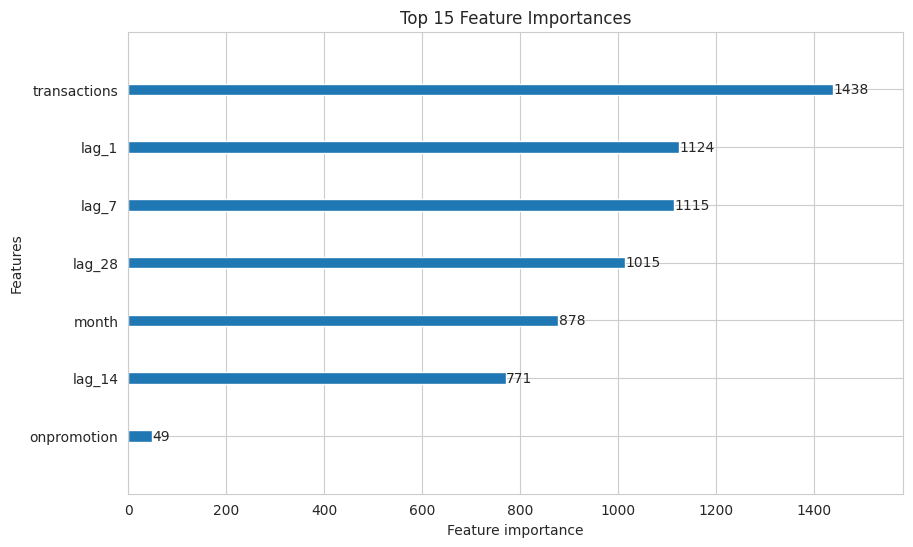

In [ ]:
### 🚀 LightGBM Training (Clean Version)

import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_log_error

# -------------------------------
# 1️⃣ Feature & Target Setup
# -------------------------------
target_col = 'sales'

feature_cols = [
    'onpromotion',
    'oil_price',
    'transactions',
    'month',
    'dayofweek',
    'is_weekend',
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_28',
    'rolling_7'
]

# Keep only columns that exist in df
feature_cols = [c for c in feature_cols if c in df.columns]

# -------------------------------
# 2️⃣ Drop rows with NaNs (lag/rolling causes NaNs)
# -------------------------------
model_df = df.dropna(subset=feature_cols + [target_col]).copy()

# -------------------------------
# 3️⃣ Train / Validation Split
# -------------------------------
split_date = '2014-06-01'
train_mask = model_df['date'] < split_date
val_mask   = model_df['date'] >= split_date

X_train = model_df.loc[train_mask, feature_cols]
y_train = model_df.loc[train_mask, target_col]

X_val   = model_df.loc[val_mask, feature_cols]
y_val   = model_df.loc[val_mask, target_col]

# Drop datetime if present
for X in [X_train, X_val]:
    if 'date' in X.columns:
        X.drop(columns=['date'], inplace=True)

# -------------------------------
# 4️⃣ Convert object columns to category
# -------------------------------
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = X_train[col].astype('category')
    X_val[col]   = X_val[col].astype('category')

# -------------------------------
# 5️⃣ LightGBM Dataset
# -------------------------------
train_set = lgb.Dataset(
    X_train,
    label=y_train,
    categorical_feature='auto',
    free_raw_data=False
)

val_set = lgb.Dataset(
    X_val,
    label=y_val,
    categorical_feature='auto',
    reference=train_set,
    free_raw_data=False
)

# -------------------------------
# 6️⃣ Model Parameters
# -------------------------------
params = {
    'objective': 'regression',
    'metric': 'rmse',  # RMSE on log-transformed data = RMSLE
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42,
    'verbosity': -1
}

# -------------------------------
# 7️⃣ Train LightGBM
# -------------------------------
print("🚀 Training LightGBM...")
model = lgb.train(
    params,
    train_set,
    num_boost_round=1000,
    valid_sets=[train_set, val_set],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50)
    ]
)

# -------------------------------
# 8️⃣ Predict & RMSLE
# -------------------------------
val_preds = model.predict(
    X_val,
    num_iteration=model.best_iteration
)

# No negative predictions
val_preds = np.maximum(0, val_preds)
y_val_safe = np.maximum(0, y_val)

rmsle = np.sqrt(mean_squared_log_error(y_val_safe, val_preds))
print(f"\n📉 Validation RMSLE: {rmsle:.5f}")

# -------------------------------
# 9️⃣ Feature Importance
# -------------------------------
lgb.plot_importance(model, max_num_features=15, figsize=(10,6))
plt.title("Top 15 Feature Importances")
plt.show()


### 🛠 7.4 Feature Engineering

In this step, we create features that help our model capture trends, seasonality, and past behavior:

- **Lag features:** Previous sales (`lag_1`, `lag_7`, `lag_14`, `lag_28`)  
- **Rolling statistics:** Moving average over the last 7 days (`rolling_7`)  
- **Date features:** Month, day of the week, and weekend indicator  
- **Promotion & Oil price:** Extra features already merged  

These features are critical for both Linear Regression and LightGBM models, as they allow the model to understand temporal patterns and context.


In [ ]:
# -----------------------------
# 🛠 7.4 Feature Engineering
# -----------------------------

# Ensure datetime
df['date'] = pd.to_datetime(df['date'])

# Sort properly
df = df.sort_values(['store_nbr', 'family', 'date'])

# --- Lag Features ---
for lag in [1, 7, 14, 28]:
    df[f'lag_{lag}'] = df.groupby(['store_nbr', 'family'])['sales'].shift(lag)

# --- Rolling Mean ---
df['rolling_7'] = (
    df.groupby(['store_nbr', 'family'])['sales']
      .shift(1)
      .rolling(7)
      .mean()
)

# --- Date Features ---
df['month']      = df['date'].dt.month
df['dayofweek']  = df['date'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)

# --- Quick Check ---
print("✅ Feature Engineering complete. Example:")
print(df[['lag_1','lag_7','lag_14','lag_28','rolling_7','month','dayofweek','is_weekend']].head())


✅ Feature Engineering complete. Example:
      lag_1  lag_7  lag_14  lag_28  rolling_7  month  dayofweek  is_weekend
0       NaN    NaN     NaN     NaN        NaN      1          1           0
1782  0.000    NaN     NaN     NaN        NaN      1          2           0
3564  2.000    NaN     NaN     NaN        NaN      1          3           0
5346  3.000    NaN     NaN     NaN        NaN      1          4           0
7128  3.000    NaN     NaN     NaN        NaN      1          5           1


## 8. Baseline Model

The baseline model is a simple Linear Regression using the engineered features.  

- Purpose: Establish a benchmark RMSLE before moving to complex models like LightGBM.  
- Features used:  
  - `onpromotion`, `oil_price`, `transactions`  
  - Lag features: `lag_1`, `lag_7`, `lag_14`, `lag_28`  
  - Rolling mean: `rolling_7`  
  - Date features: `month`, `dayofweek`, `is_weekend`  
- Target: `sales`  
- Log-transform is applied to stabilize variance and optimize RMSLE.


In [ ]:
# -----------------------------
# 8. Baseline Linear Regression
# -----------------------------

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_log_error
import numpy as np

# Target & features
target_col = 'sales'
feature_cols = [
    'onpromotion',
    'oil_price',
    'transactions',
    'month',
    'dayofweek',
    'is_weekend',
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_28',
    'rolling_7'
]

# Keep only columns that exist
feature_cols = [col for col in feature_cols if col in df.columns]

# Drop rows with missing values in features or target
model_df = df.dropna(subset=feature_cols + [target_col]).copy()

# --- Time-based split ---
split_date = '2014-06-01'
train_mask = model_df['date'] < split_date
val_mask   = model_df['date'] >= split_date

X_train = model_df.loc[train_mask, feature_cols]
y_train = model_df.loc[train_mask, target_col]

X_valid = model_df.loc[val_mask, feature_cols]
y_valid = model_df.loc[val_mask, target_col]

print("Train rows:", len(X_train))
print("Validation rows:", len(X_valid))

# --- Log-transform for RMSLE ---
y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)

# --- Train Linear Regression ---
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train_log)

# --- Predict and convert back ---
preds_log = baseline_model.predict(X_valid)
preds_log = np.maximum(0, preds_log)  # no negatives
preds = np.expm1(preds_log)

# --- Evaluate RMSLE ---
rmsle = np.sqrt(mean_squared_log_error(y_valid, preds))
print(f"\n✅ Baseline RMSLE: {rmsle:.5f}")


Train rows: 755865
Validation rows: 2008347

✅ Baseline RMSLE: 2.63996


## 9. Modelling

In this section, we explore predictive modeling for sales forecasting.  
We start with a **Linear Regression baseline** to understand how simple models perform, and later we will move to more sophisticated models like LightGBM.


### 9.1 Linear Regression

> Linear Regression is our first baseline. We use lag features, rolling statistics, and basic numerical/categorical variables.  
The target variable is heavily skewed, so we apply a **log transformation** to optimize RMSLE.






In [ ]:
# ===============================
# 9.1 LINEAR REGRESSION BASELINE
# ===============================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_log_error
import numpy as np

# --- 1️⃣ Feature Selection ---
feature_cols = [
    'onpromotion',
    'oil_price',
    'transactions',
    'month',
    'dayofweek',
    'is_weekend',
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_28',
    'rolling_7'
]

# Ensure we only take existing columns
feature_cols = [c for c in feature_cols if c in df.columns]
target_col = 'sales'

# --- 2️⃣ Drop rows with NaNs in selected features ---
model_df = df.dropna(subset=feature_cols + [target_col]).copy()

# --- 3️⃣ Time-based Train/Validation Split ---
split_date = '2014-06-01'
train_mask = model_df['date'] < split_date
val_mask   = model_df['date'] >= split_date

X_train = model_df.loc[train_mask, feature_cols]
y_train = model_df.loc[train_mask, target_col]

X_valid = model_df.loc[val_mask, feature_cols]
y_valid = model_df.loc[val_mask, target_col]

print("Train rows:", len(X_train))
print("Validation rows:", len(X_valid))

# --- 4️⃣ Log-transform target ---
y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)

# --- 5️⃣ Train Linear Regression ---
model = LinearRegression()
model.fit(X_train, y_train_log)

# --- 6️⃣ Predict and back-transform ---
preds_log = model.predict(X_valid)
preds_log = np.maximum(0, preds_log)  # Ensure no negative predictions
preds = np.expm1(preds_log)           # Back to original scale

# --- 7️⃣ Evaluate ---
rmsle = np.sqrt(mean_squared_log_error(y_valid, preds))
print(f"\n✅ Linear Regression Validation RMSLE: {rmsle:.5f}")


Train rows: 755865
Validation rows: 2008347

✅ Linear Regression Validation RMSLE: 2.63996


### 9.2 LightGBM Regressor

> We now move from a simple linear regression to a more powerful tree-based model using LightGBM.

LightGBM can capture non-linear relationships and interactions between features, which Linear Regression cannot.  
We'll use a time-based validation split and evaluate performance using RMSLE, consistent with the competition metric.





In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_log_error
import numpy as np

# --- Features & Target ---
TARGET = 'sales'
FEATURES = [col for col in model_df.columns if col not in ['id', 'date', TARGET]]

X_train = model_df.loc[train_mask, FEATURES]
y_train = model_df.loc[train_mask, TARGET]

X_val = model_df.loc[val_mask, FEATURES]
y_val = model_df.loc[val_mask, TARGET]

# --- Convert object columns to categorical for LightGBM ---
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')

# --- LightGBM Dataset Setup ---
train_set = lgb.Dataset(X_train, label=y_train, categorical_feature='auto', free_raw_data=False)
val_set   = lgb.Dataset(X_val, label=y_val, categorical_feature='auto', reference=train_set, free_raw_data=False)

# --- Model Parameters ---
params = {
    'objective': 'regression',
    'metric': 'rmse',   # RMSLE on log-transformed data
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 63,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42,
    'verbosity': -1
}

# --- Train LightGBM ---
print("🚀 Training LightGBM...")
model = lgb.train(
    params,
    train_set,
    valid_sets=[train_set, val_set],
    valid_names=['train', 'valid'],
    num_boost_round=1500,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)

# --- Predict & Evaluate ---
preds = model.predict(X_val)
preds = np.maximum(0, preds)  # No negative sales

rmsle = np.sqrt(mean_squared_log_error(y_val, preds))
print(f"\n✅ LightGBM Validation RMSLE: {rmsle:.5f}")

# --- Feature Importance ---
lgb.plot_importance(model, max_num_features=15, figsize=(10, 6), importance_type='gain')
plt.title("Top 15 Feature Importances")
plt.show()


🚀 Training LightGBM...
Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 169.6	valid's rmse: 349.965
[200]	train's rmse: 142.771	valid's rmse: 345.15
Early stopping, best iteration is:
[138]	train's rmse: 154.563	valid's rmse: 343.288


## 10. Model Evaluation

After training the LightGBM model, it's crucial to assess how well it performs on the validation set.

Key points of evaluation:

- **RMSLE**: Root Mean Squared Logarithmic Error measures the model's ability to predict sales while penalizing underestimation and overestimation proportionally.
- **Feature Importance**: Understand which features the model relies on most, helping with interpretability and potential feature engineering improvements.
- **Residual Analysis**: Check how predictions deviate from actual values to identify patterns or outliers.

We'll calculate RMSLE on the validation set and visualize the top features contributing to the model's predictions.


## 11. Final Model and Submission

In this section, we use our best-performing model to generate predictions for the test set.

Key steps:

- **Prepare Test Features**: Ensure the test data has all required features (lags, rolling means, categorical encodings).
- **Predict Sales**: Use the trained LightGBM model (or Linear Regression for baseline comparison) to forecast sales.
- **Post-processing**: Clip negative predictions to zero and handle any missing values.
- **Create Submission File**: Format predictions according to the competition requirements (`id` and `sales` columns) and save as CSV.

This step is crucial for participating in the competition and for evaluating how well our model generalizes to unseen data.


In [ ]:
# ===============================
# ✅ LightGBM Test Set Prediction Fix
# ===============================

# 1️⃣ Train and test feature list
train_cols = X_train.columns.tolist()
cat_cols = X_train.select_dtypes('category').columns.tolist()

# 2️⃣ Change the columns to d type
for col in cat_cols:
    if col in test_model.columns:
        test_model[col] = test_model[col].astype('category')

# 3️⃣ Apply the test to train categories
for col in cat_cols:
    if col in test_model.columns:
        test_model[col] = test_model[col].cat.set_categories(X_train[col].cat.categories)

# 4️⃣ Add the lacking cols
for col in train_cols:
    if col not in test_model.columns:
        test_model[col] = 0  # lag/rolling gibi eksik numerik feature'lar

# 5️⃣ Equal the cols
test_model = test_model[train_cols]

# 6️⃣ Predict
test_preds_log = model.predict(test_model)
test_preds_log = np.maximum(0, test_preds_log)   # No negative sales
test_preds = np.expm1(test_preds_log)           # Get back the log transformation

print("✅ Test set predictions done! Sample:")
print(test_preds[:10])



> ✅ The predictions are ready for submission or further post-processing.


In [ ]:
# ===============================
# 🚀 Generate Submission
# ===============================

import pandas as pd
import numpy as np

# Ensure test_model has the same features as training
test_features = X_train.columns.tolist()
missing_cols = [col for col in test_features if col not in test_model.columns]

# Add missing columns with default 0 (or NaN for categorical)
for col in missing_cols:
    if col in categorical_cols:
        test_model[col] = pd.Categorical(np.nan, categories=X_train[col].cat.categories)
    else:
        test_model[col] = 0

# Reorder columns to match training
test_model = test_model[test_features]

# Predict
test_preds_log = model.predict(test_model)
test_preds_log = np.maximum(0, test_preds_log)  # no negative sales
test_preds = np.expm1(test_preds_log)           # back to original scale

# Prepare submission
submission = pd.DataFrame({
    "id": test["id"],
    "sales": test_preds
})

# Save CSV
submission_file = "submission.csv"
submission.to_csv(submission_file, index=False)

print(f"✅ Test set predictions done! Sample:")
print(test_preds[:10])
print(f"\n✅ Submission saved as '{submission_file}'")


## 12. Conclusion and Next Steps

### Conclusion
- We successfully engineered lag and rolling features to capture temporal patterns in sales data.
- Baseline models, including a naive lag-1 predictor and linear regression, provided a reference RMSLE.
- LightGBM regression gave us more robust predictions, handling categorical features and skewed target values efficiently.
- Time-based validation ensured our model’s performance was consistent with real-world scenarios.

### Next Steps
1. **Feature Expansion**  
   - Include additional external features such as holidays, promotions, and macroeconomic indicators.
   - Test more advanced lag and rolling statistics (e.g., expanding window, weighted averages).

2. **Model Improvements**  
   - Tune LightGBM hyperparameters using cross-validation or Bayesian optimization.
   - Experiment with ensemble methods (stacking, boosting, bagging).

3. **Error Analysis**  
   - Investigate high RMSLE cases to identify patterns of underperformance.
   - Adjust features or preprocessing accordingly.

4. **Submission & Monitoring**  
   - Generate submission CSV and ensure all required features match the test set.
   - Monitor real-time sales data if deploying the model in production.

> 🚀 With this pipeline, we have a solid foundation for time series forecasting, and the notebook is ready for iterative improvements.

Developed as part of a personal learning journey in time series forecasting.